<a href="https://colab.research.google.com/github/yanaguntikarmeesal/Agentic-AI-Weather-Assistant-Project/blob/main/Agent_Project__1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Complete Agentic AI Weather Assistant Project

# **🌦️ Agentic AI Weather Assistant**

# Technologies used

* Python

* LangChain

* Groq LLM — Llama 3.3 70B Versatile

* LangGraph memory

* Weather data from wttr.in

* Google Colab

# Features

* Get current weather for a city.

* Automatically call a weather tool.

* Maintain conversation history.

* Ask follow-up questions.

* Handle common errors.

# Cell 1 — Install required libraries

In [ ]:
%pip install -q -U langchain langchain-groq langgraph requests==2.32.4'

# Cell 2 — Enter your Groq API key

Where do you enter the API key? After running this cell, Colab will display a secure input prompt. Paste your newly generated Groq API key there and press Enter.

In [ ]:
import os
from getpass import getpass

# Remove any previously stored key
os.environ.pop("GROQ_API_KEY", None)

# Enter your new API key in the hidden prompt
api_key = getpass("Enter your Groq API key: ").strip()

if not api_key.startswith("gsk_"):
    raise ValueError(
        "Invalid API key format. Please check your Groq API key."
    )

os.environ["GROQ_API_KEY"] = api_key

print("✅ Groq API key configured successfully!")



# Cell 3 — Import libraries

In [ ]:
import requests

from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

print("✅ All libraries imported successfully!")

# Cell 4 — Create the weather tool

The weather tool fetches current weather information for a city using the wttr.in service.

In [ ]:
@tool
def get_weather(city: str) -> str:
    """
    Get current weather information for a city.

    Args:
        city: City name, such as Bengaluru, Mumbai, or Delhi.
    """

    city = city.strip()

    if not city:
        return "Please provide a valid city name."

    url = f"https://wttr.in/{requests.utils.quote(city)}"

    try:
        response = requests.get(
            url,
            params={"format": "j1"},
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=20
        )

        response.raise_for_status()
        data = response.json()

        current = data["current_condition"][0]

        temperature = current["temp_C"]
        feels_like = current["FeelsLikeC"]
        condition = current["weatherDesc"][0]["value"]
        humidity = current["humidity"]
        wind_speed = current["windspeedKmph"]

        return (
            f"Weather in {city}:\n"
            f"Condition: {condition}\n"
            f"Temperature: {temperature}°C\n"
            f"Feels like: {feels_like}°C\n"
            f"Humidity: {humidity}%\n"
            f"Wind speed: {wind_speed} km/h"
        )

    except requests.exceptions.Timeout:
        return "Weather service timed out. Please try again."

    except requests.exceptions.RequestException as e:
        return f"Weather service error: {e}"

    except (KeyError, IndexError, ValueError):
        return "Could not retrieve weather data for this city."

# Test the weather tool

In [ ]:
weather_result = get_weather.invoke(
    {"city": "Bengaluru"}
)

print(weather_result)

# Cell 5 — Initialize the Groq LLM

The LLM understands questions and decides when to use the weather tool.

In [ ]:
from langchain_groq import ChatGroq
import os

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=os.environ["GROQ_API_KEY"]
)

# Test the model
test_response = llm.invoke(
    "Say hello in one short sentence."
)

print(test_response.content)

# Step 2 — Recreate your agent

After the test succeeds, run this cell to connect the new model to your existing weather tool and memory.

In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt=(
        "You are a helpful weather assistant. "
        "Use the get_weather tool for current weather questions. "
        "Never invent weather information."
    ),
    checkpointer=memory
)

config = {
    "configurable": {
        "thread_id": "weather_chat_1"
    }
}

print("✅ Agent recreated successfully!")

# Step 3 — Test the weather assistant

In [ ]:
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is the weather in Bengaluru?"
            }
        ]
    },
    config=config
)

print(response["messages"][-1].content)

# Cell 8 — Run the interactive chatbot

This is the main chatbot loop. You can ask multiple questions in the same conversation.

In [ ]:
print("🌦️ Agentic AI Weather Assistant")
print("Ask about the weather in any city.")
print("Type 'exit' to stop.\n")

while True:

    user_input = input("You: ").strip()

    if user_input.lower() == "exit":
        print("Assistant: Goodbye! Have a nice day.")
        break

    if not user_input:
        print("Please enter a message.\n")
        continue

    try:
        response = agent.invoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": user_input
                    }
                ]
            },
            config=config
        )

        # Find the latest assistant response
        answer = next(
            (
                message.content
                for message in reversed(response["messages"])
                if message.type == "ai" and message.content
            ),
            "Sorry, I could not generate a response."
        )

        # Handle text responses
        if isinstance(answer, list):
            answer = "\n".join(
                item.get("text", "")
                for item in answer
                if isinstance(item, dict)
            )

        print(f"\nAssistant: {answer}\n")

    except Exception as e:
        print(f"\n❌ Error: {e}\n")
        print(
            "Check your Groq API key, model availability, "
            "and internet connection.\n"
        )

* You: What is the weather in Bengaluru?

* You: What about Mumbai?

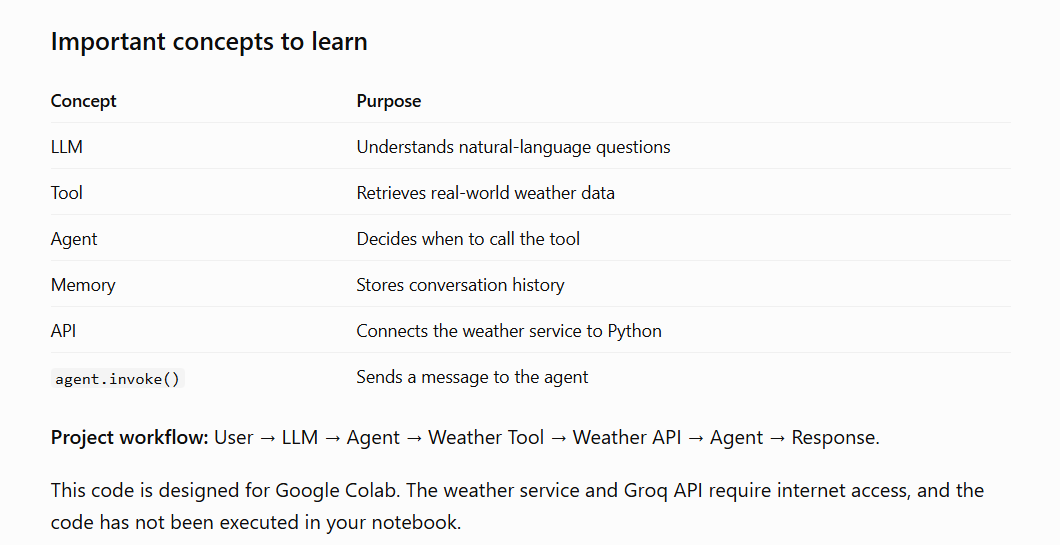